[nltk_data] Downloading package stopwords to
[nltk_data]     /home/cse23160/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/cse23160/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


FHE-ENABLED LINEAR SVM FOR PUBMED RCT CLASSIFICATION
FINAL VERSION - USING CONCRETE-ML LINEARSVC

Loading datasets...
Train set: 180040 samples
Dev set: 30212 samples
Test set: 30135 samples

DATASET ANALYSIS FOR SVM


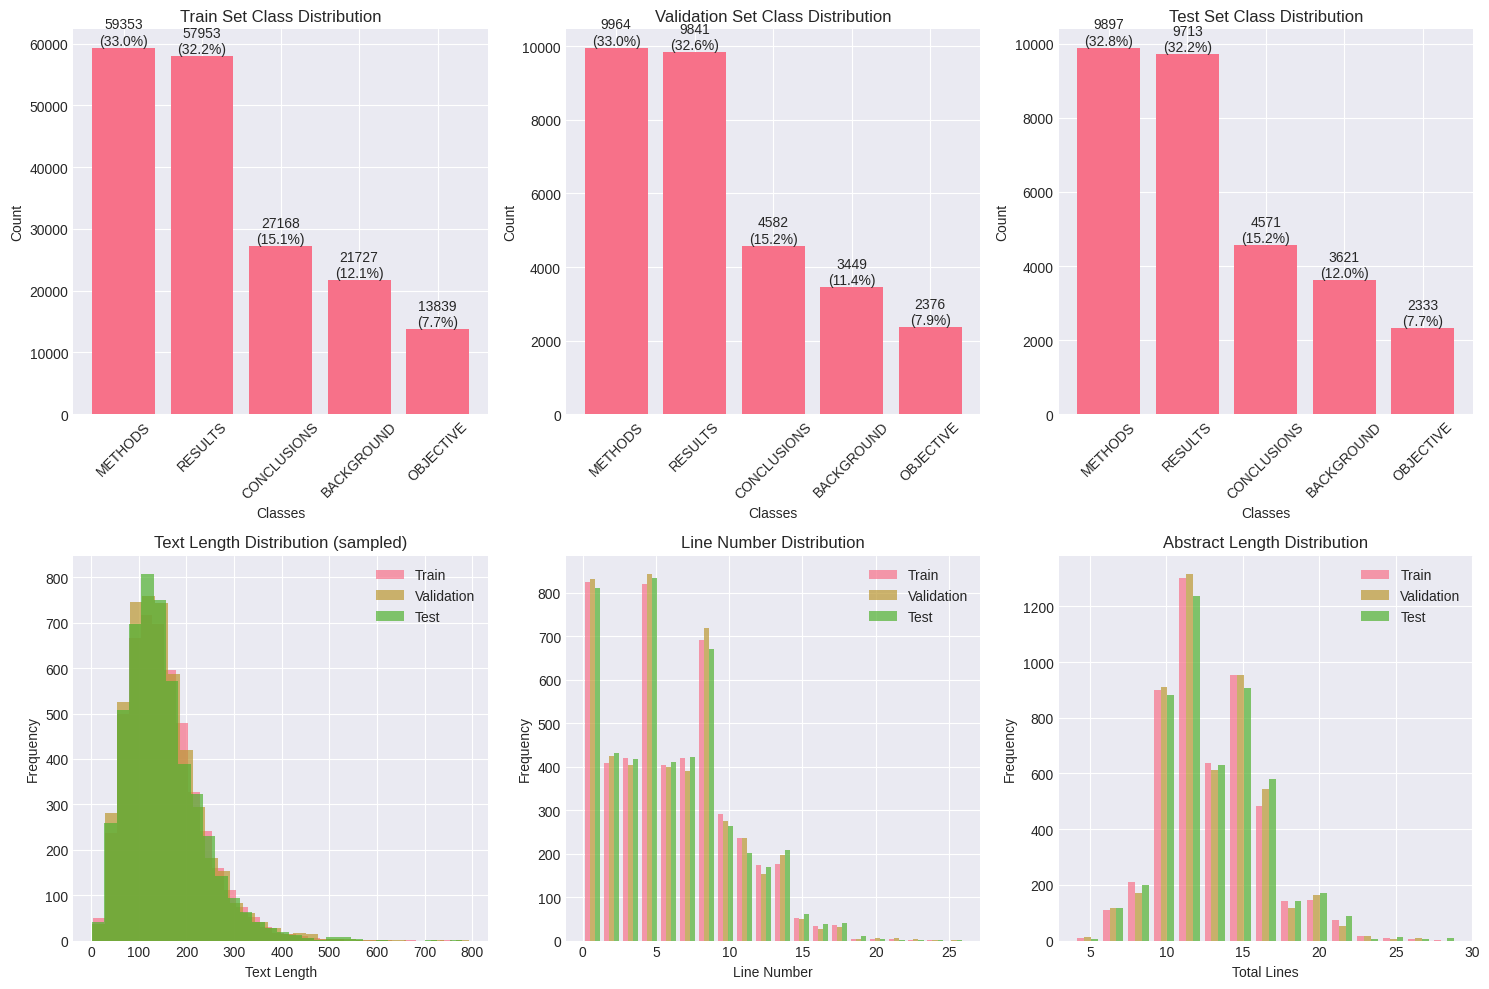


Dataset Statistics:
----------------------------------------

Train Set:
  Total samples: 180040
  Average text length: 152.0
  Average lines per abstract: 12.8

Validation Set:
  Total samples: 30212
  Average text length: 151.9
  Average lines per abstract: 12.9

Test Set:
  Total samples: 30135
  Average text length: 151.1
  Average lines per abstract: 12.8

LINEAR SVM MODEL TRAINING (Memory-Optimized)
Preparing training features...
Training set size: (180040, 20002)
Feature matrix memory: 23.83 MB
Number of classes: 5

Training scikit-learn Linear SVM model (sparse)...

Scikit-learn Linear SVM performance on dev set:
              precision    recall  f1-score   support

  BACKGROUND       0.67      0.70      0.69      3449
 CONCLUSIONS       0.87      0.89      0.88      4582
     METHODS       0.88      0.89      0.89      9964
   OBJECTIVE       0.62      0.61      0.61      2376
     RESULTS       0.89      0.86      0.87      9841

    accuracy                           0.84 

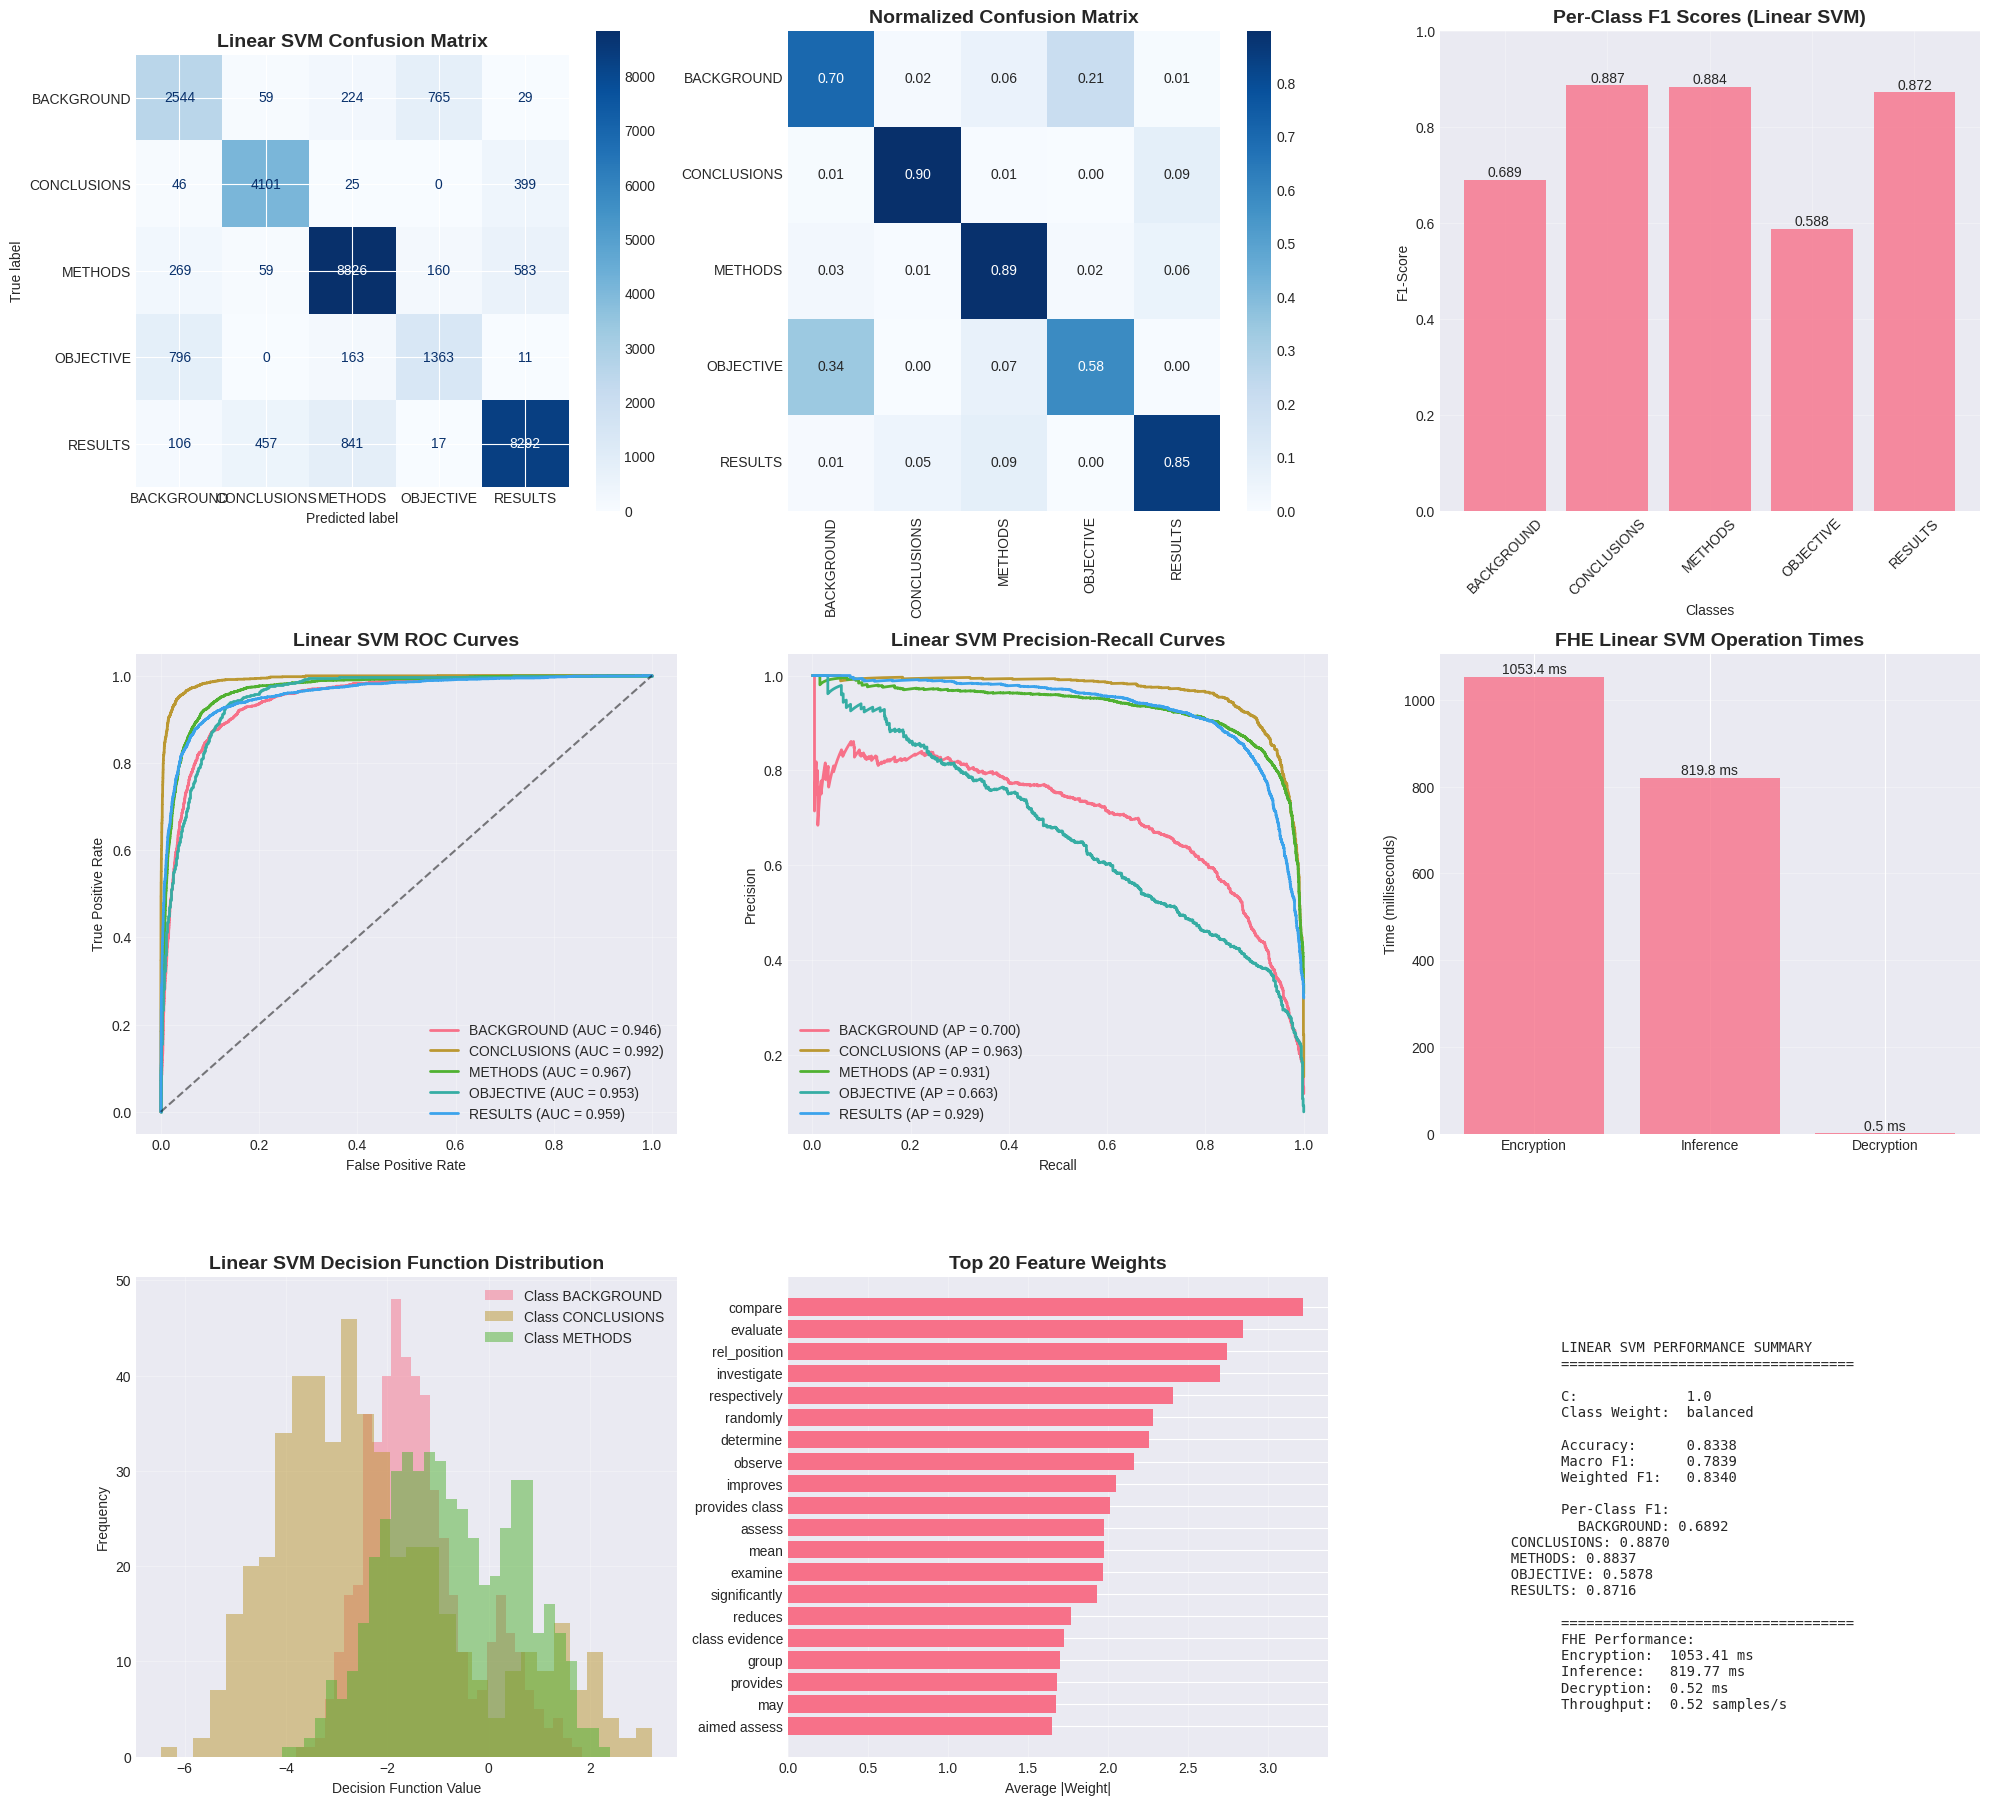


Visualizations saved to 'fhe_svm_complete_analysis.png'

SAVING LINEAR SVM MODEL
Model data saved to fhe_svm_pubmed_classifier_final.joblib
Note: FHE Linear SVM model not saved. Will need retraining when loading.

FHE LINEAR SVM IMPLEMENTATION COMPLETE!

Generated Files:
  1. svm_dataset_analysis.png - Dataset analysis visualizations
  2. fhe_svm_complete_analysis.png - Complete Linear SVM analysis dashboard
  3. fhe_svm_pubmed_classifier_final.joblib - Linear SVM model data

TESTING LINEAR SVM MODEL LOADING

LOADING LINEAR SVM MODEL
Model loaded from fhe_svm_pubmed_classifier_final.joblib
FHE Linear SVM model not loaded. Use train_fhe_from_scratch() to train FHE model.

Training FHE Linear SVM model from scratch...

TRAINING FHE LINEAR SVM MODEL FROM SCRATCH
Extracting 10000 samples for FHE Linear SVM training...
Sample shape: (10000, 20002)
Sample memory: 800.08 MB
Scaling features for FHE Linear SVM...
Training FHE Linear SVM model on sample...
Quantization parameters: scale=6.2293

In [2]:
"""
FHE-Enabled SVM for PubMed RCT Classification
Fixed Version - Using only available Concrete-ML SVM classes
"""

import numpy as np
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (classification_report, accuracy_score, f1_score,
                           precision_score, recall_score, confusion_matrix,
                           ConfusionMatrixDisplay, roc_curve, auc,
                           precision_recall_curve, average_precision_score)
from scipy.sparse import hstack, csr_matrix, save_npz, load_npz
import joblib
import warnings
import time
import gc
import os
warnings.filterwarnings('ignore')

# Concrete-ML imports for FHE
# Note: Concrete-ML only has LinearSVC, not SVM class
from concrete.ml.sklearn import LinearSVC as ConcreteLinearSVC

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
STOPWORDS = set(stopwords.words('english'))

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Standalone tokenizer function for pickling
def tokenizer(text):
    """Standalone tokenizer function for pickling"""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

class FHEPubMedSVMClassifier:
    """
    Memory-optimized FHE Linear SVM classifier for PubMed RCT classification
    Using Concrete-ML's LinearSVC for FHE compatibility
    """
    
    def __init__(self, memory_efficient=True, max_features=20000, 
                 C=1.0, class_weight='balanced'):
        """
        Initialize FHE SVM classifier
        
        Args:
            memory_efficient: Use memory optimization techniques
            max_features: Maximum features for TF-IDF vectorizer
            C: Regularization parameter
            class_weight: Class weighting strategy
        """
        self.vectorizer = None
        self.label_encoder = LabelEncoder()
        self.scaler = StandardScaler(with_mean=False)  # Can't use with_mean for sparse
        self.fhe_model = None
        self.trained_model = None
        self.is_fhe_compiled = False
        self.fhe_circuit = None
        self.training_history = {}
        self.class_names = None
        self.memory_efficient = memory_efficient
        self.max_features = max_features
        self.quantization_params = None
        self.C = C
        self.class_weight = class_weight
        self.n_classes = None
        
    def process_text(self, text):
        """Text preprocessing function - kept for backward compatibility"""
        return tokenizer(text)
    
    def prepare_features(self, df, fit_vectorizer=False):
        """Memory-efficient feature preparation"""
        if fit_vectorizer:
            self.vectorizer = TfidfVectorizer(
                tokenizer=tokenizer,
                ngram_range=(1, 2),
                max_features=self.max_features,
                token_pattern=None,
                dtype=np.float32
            )
            X_text = self.vectorizer.fit_transform(df['abstract_text'])
        else:
            X_text = self.vectorizer.transform(df['abstract_text'])
        
        # Position features
        rel_pos = (df['line_number'] / df['total_lines']).values.reshape(-1, 1)
        line_num = df['line_number'].values.reshape(-1, 1)
        
        # Combine all features
        X = hstack([X_text, rel_pos, line_num])
        
        return X
    
    def extract_samples(self, X_sparse, indices):
        """Extract samples from sparse matrix using indices"""
        X_csr = X_sparse.tocsr()
        X_sample = X_csr[indices].toarray().astype(np.float32)
        return X_sample
    
    def analyze_dataset(self, train_df, dev_df, test_df):
        """Perform comprehensive dataset analysis"""
        print("\n" + "="*60)
        print("DATASET ANALYSIS FOR SVM")
        print("="*60)
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        datasets = {'Train': train_df, 'Validation': dev_df, 'Test': test_df}
        
        for idx, (name, df) in enumerate(datasets.items()):
            ax = axes[0, idx]
            class_counts = df['target'].value_counts()
            self.class_names = class_counts.index.tolist()
            
            bars = ax.bar(range(len(class_counts)), class_counts.values)
            ax.set_title(f'{name} Set Class Distribution')
            ax.set_xlabel('Classes')
            ax.set_ylabel('Count')
            ax.set_xticks(range(len(class_counts)))
            ax.set_xticklabels(class_counts.index, rotation=45)
            
            for bar, count in zip(bars, class_counts.values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{count}\n({count/len(df)*100:.1f}%)',
                       ha='center', va='bottom')
        
        ax = axes[1, 0]
        for name, df in datasets.items():
            sample_texts = df['abstract_text'].sample(min(5000, len(df))).str.len()
            ax.hist(sample_texts, label=name, bins=30, alpha=0.7)
        ax.set_title('Text Length Distribution (sampled)')
        ax.set_xlabel('Text Length')
        ax.set_ylabel('Frequency')
        ax.legend()
        
        ax = axes[1, 1]
        ax.hist([train_df['line_number'].sample(5000), 
                dev_df['line_number'].sample(5000),
                test_df['line_number'].sample(5000)],
                label=['Train', 'Validation', 'Test'], bins=20, alpha=0.7)
        ax.set_title('Line Number Distribution')
        ax.set_xlabel('Line Number')
        ax.set_ylabel('Frequency')
        ax.legend()
        
        ax = axes[1, 2]
        ax.hist([train_df['total_lines'].sample(5000),
                dev_df['total_lines'].sample(5000),
                test_df['total_lines'].sample(5000)],
                label=['Train', 'Validation', 'Test'], bins=15, alpha=0.7)
        ax.set_title('Abstract Length Distribution')
        ax.set_xlabel('Total Lines')
        ax.set_ylabel('Frequency')
        ax.legend()
        
        plt.tight_layout()
        plt.savefig('svm_dataset_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\nDataset Statistics:")
        print("-"*40)
        for name, df in datasets.items():
            print(f"\n{name} Set:")
            print(f"  Total samples: {len(df)}")
            print(f"  Average text length: {df['abstract_text'].str.len().mean():.1f}")
            print(f"  Average lines per abstract: {df['total_lines'].mean():.1f}")
    
    def train(self, train_df, dev_df):
        """Memory-optimized training for Linear SVM"""
        print("\n" + "="*60)
        print("LINEAR SVM MODEL TRAINING (Memory-Optimized)")
        print("="*60)
        
        start_time = time.time()
        
        print("Preparing training features...")
        X_train = self.prepare_features(train_df, fit_vectorizer=True)
        X_dev = self.prepare_features(dev_df, fit_vectorizer=False)
        
        # Prepare labels
        y_train = train_df['target']
        y_dev = dev_df['target']
        
        y_train_enc = self.label_encoder.fit_transform(y_train)
        y_dev_enc = self.label_encoder.transform(y_dev)
        self.class_names = self.label_encoder.classes_
        self.n_classes = len(self.class_names)
        
        print(f"Training set size: {X_train.shape}")
        print(f"Feature matrix memory: {X_train.data.nbytes / 1e6:.2f} MB")
        print(f"Number of classes: {self.n_classes}")
        
        # Train scikit-learn Linear SVM model
        print("\nTraining scikit-learn Linear SVM model (sparse)...")
        
        self.trained_model = LinearSVC(
            C=self.C,
            max_iter=2000,
            class_weight=self.class_weight,
            random_state=42,
            dual=False  # Prefer primal for large datasets
        )
        
        self.trained_model.fit(X_train, y_train_enc)
        
        # Evaluate
        y_dev_pred = self.trained_model.predict(X_dev)
        
        print("\nScikit-learn Linear SVM performance on dev set:")
        print(classification_report(y_dev_enc, y_dev_pred, 
                                  target_names=self.class_names))
        
        self.training_history['dev_accuracy'] = accuracy_score(y_dev_enc, y_dev_pred)
        self.training_history['dev_f1_macro'] = f1_score(y_dev_enc, y_dev_pred, average='macro')
        self.training_history['training_time'] = time.time() - start_time
        
        # For FHE, train on a representative sample
        print("\nPreparing sample for FHE Linear SVM model...")
        
        # Get sample indices
        n_samples_train = X_train.shape[0]
        sample_size = min(10000, n_samples_train)
        sample_indices = np.random.choice(n_samples_train, sample_size, replace=False)
        
        # Extract samples
        print(f"Extracting {sample_size} samples for FHE training...")
        X_train_sample = self.extract_samples(X_train, sample_indices)
        y_train_sample = y_train_enc[sample_indices]
        
        print(f"Sample shape: {X_train_sample.shape}")
        print(f"Sample memory: {X_train_sample.nbytes / 1e6:.2f} MB")
        
        # Scale features for better SVM performance
        print("Scaling features for FHE Linear SVM...")
        self.scaler.fit(X_train_sample)
        X_train_sample_scaled = self.scaler.transform(X_train_sample)
        
        # Train FHE Linear SVM model
        print("Training FHE Linear SVM model on sample...")
        
        self.fhe_model = ConcreteLinearSVC(
            n_bits=7,
            C=self.C,
            max_iter=100,
            random_state=42,
            class_weight={i: 1.0 for i in range(self.n_classes)}  # Convert to dict if needed
        )
        
        self.fhe_model.fit(X_train_sample_scaled, y_train_sample)
        
        # Get quantization parameters from the model
        if hasattr(self.fhe_model, 'input_quantizers') and self.fhe_model.input_quantizers:
            quantizer = self.fhe_model.input_quantizers[0]
            self.quantization_params = {
                'scale': float(quantizer.scale),
                'zero_point': int(quantizer.zero_point),
                'n_bits': int(quantizer.n_bits),
                'is_signed': bool(quantizer.is_signed),
            }
            print(f"Quantization parameters: scale={quantizer.scale:.4f}, zero_point={quantizer.zero_point}")
        
        # Clear sample data
        del X_train_sample, X_train_sample_scaled, y_train_sample
        gc.collect()
        
        print(f"FHE Linear SVM training complete. Total time: {time.time() - start_time:.2f} seconds")
        
        return self
    
    def compile_for_fhe(self):
        """Compile the Linear SVM model for FHE inference"""
        if self.fhe_model is None:
            raise ValueError("Model not trained yet. Call train() first.")
        
        print("\n" + "="*60)
        print("FHE LINEAR SVM COMPILATION")
        print("="*60)
        
        start_time = time.time()
        
        # Create a minimal sample for compilation
        print("Creating compilation sample...")
        X_sample = self.vectorizer.transform(["Sample text for compilation"]).toarray().astype(np.float32)
        sample_features = np.hstack([X_sample, [[0.5, 5]]])
        
        # Scale the sample
        sample_features_scaled = self.scaler.transform(sample_features)
        
        # Compile the model
        print("Compiling Linear SVM model for FHE inference (this may take 2-5 minutes)...")
        self.fhe_circuit = self.fhe_model.compile(sample_features_scaled)
        self.is_fhe_compiled = True
        
        compile_time = time.time() - start_time
        self.training_history['compile_time'] = compile_time
        
        print(f"FHE Linear SVM compilation complete! Time: {compile_time:.2f} seconds")
        
        return self
    
    def quantize_for_fhe(self, X_float):
        """
        Quantize float features to integers for FHE using the model's parameters
        """
        if self.quantization_params is None:
            # If no quantization params, use a simple scaling to int24 range
            max_int = 2**23 - 1
            min_int = -2**23
            
            # Clip extreme values and scale
            X_clipped = np.clip(X_float, -10, 10)
            X_scaled = (X_clipped * max_int / 10).astype(np.int32)
            X_quantized = np.clip(X_scaled, min_int, max_int)
            return X_quantized
        else:
            # Use the model's quantization parameters
            scale = self.quantization_params['scale']
            zero_point = self.quantization_params['zero_point']
            n_bits = self.quantization_params['n_bits']
            is_signed = self.quantization_params['is_signed']
            
            # Calculate min/max for the integer range
            if is_signed:
                min_int = -2**(n_bits-1)
                max_int = 2**(n_bits-1) - 1
            else:
                min_int = 0
                max_int = 2**n_bits - 1
            
            # Quantize
            X_scaled = X_float / scale + zero_point
            X_rounded = np.round(X_scaled)
            X_quantized = np.clip(X_rounded, min_int, max_int).astype(np.int32)
            
            return X_quantized
    
    def predict_encrypted_batch(self, texts, line_numbers, total_lines, batch_size=5):
        """
        Perform prediction on encrypted data - quantize first, then encrypt
        """
        if not self.is_fhe_compiled:
            raise ValueError("Model not compiled for FHE. Call compile_for_fhe() first.")
        
        start_time = time.time()
        
        n_samples = len(texts)
        predictions = []
        confidences = []
        encryption_times = []
        inference_times = []
        decryption_times = []
        
        print(f"\nPerforming encrypted Linear SVM inference on {n_samples} samples...")
        
        for i in range(0, n_samples, batch_size):
            batch_end = min(i + batch_size, n_samples)
            batch_texts = texts[i:batch_end]
            batch_line_numbers = line_numbers[i:batch_end]
            batch_total_lines = total_lines[i:batch_end]
            
            # Prepare features as float32
            X_text = self.vectorizer.transform(batch_texts).toarray().astype(np.float32)
            rel_pos = (batch_line_numbers / batch_total_lines).reshape(-1, 1).astype(np.float32)
            line_num = batch_line_numbers.reshape(-1, 1).astype(np.float32)
            
            X_batch_float = np.hstack([X_text, rel_pos, line_num])
            
            # Scale features
            X_batch_scaled = self.scaler.transform(X_batch_float)
            
            # Quantize to integers
            X_batch_quantized = self.quantize_for_fhe(X_batch_scaled)
            
            for j, x in enumerate(X_batch_quantized):
                # Ensure correct shape
                x_input = x.reshape(1, -1)
                
                # Time encryption
                t1 = time.time()
                encrypted_sample = self.fhe_circuit.encrypt(x_input)
                encryption_times.append(time.time() - t1)
                
                # Time inference
                t2 = time.time()
                encrypted_result = self.fhe_circuit.run(encrypted_sample)
                inference_times.append(time.time() - t2)
                
                # Time decryption
                t3 = time.time()
                result = self.fhe_circuit.decrypt(encrypted_result)
                decryption_times.append(time.time() - t3)
                
                # For Linear SVM, result is the decision function values
                # Multi-class: one-vs-rest, so we get scores for each class
                pred_class = np.argmax(result[0])
                
                # Convert decision function to pseudo-probability using softmax
                # This gives a confidence-like score
                exp_scores = np.exp(result[0] - np.max(result[0]))
                probs = exp_scores / np.sum(exp_scores)
                pred_confidence = np.max(probs)
                
                predictions.append(pred_class)
                confidences.append(pred_confidence)
            
            print(f"Processed batch {i//batch_size + 1}/{(n_samples + batch_size - 1)//batch_size}")
            
            # Clear batch data
            del X_batch_float, X_batch_scaled, X_batch_quantized, X_text
            gc.collect()
        
        total_time = time.time() - start_time
        
        # Calculate performance metrics
        performance = {
            'encryption_time': np.mean(encryption_times),
            'inference_time': np.mean(inference_times),
            'decryption_time': np.mean(decryption_times),
            'total_time': total_time,
            'samples_per_second': n_samples / total_time
        }
        
        print(f"\nFHE Linear SVM Performance Summary:")
        print(f"  Average encryption time: {performance['encryption_time']*1000:.2f} ms")
        print(f"  Average inference time: {performance['inference_time']*1000:.2f} ms")
        print(f"  Average decryption time: {performance['decryption_time']*1000:.2f} ms")
        print(f"  Total time: {total_time:.2f} seconds")
        print(f"  Throughput: {performance['samples_per_second']:.2f} samples/second")
        
        return np.array(predictions), np.array(confidences), performance
    
    def predict_clear(self, texts, line_numbers, total_lines):
        """Perform prediction on clear (non-encrypted) data"""
        if self.trained_model is None:
            raise ValueError("Model not trained yet.")
        
        X_text = self.vectorizer.transform(texts).toarray().astype(np.float32)
        rel_pos = (line_numbers / total_lines).reshape(-1, 1)
        line_num = line_numbers.reshape(-1, 1)
        
        X = np.hstack([X_text, rel_pos, line_num])
        
        start_time = time.time()
        predictions = self.trained_model.predict(X)
        
        # For LinearSVC, approximate probabilities using decision function
        decision = self.trained_model.decision_function(X)
        
        # Convert to pseudo-probabilities using softmax
        exp_scores = np.exp(decision - np.max(decision, axis=1, keepdims=True))
        probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        
        inference_time = time.time() - start_time
        
        return predictions, probabilities, inference_time
    
    def evaluate(self, test_df):
        """Evaluate Linear SVM model performance on test set"""
        print("\n" + "="*60)
        print("LINEAR SVM MODEL EVALUATION")
        print("="*60)
        
        start_time = time.time()
        
        X_test = self.prepare_features(test_df, fit_vectorizer=False)
        y_test = test_df['target']
        y_test_enc = self.label_encoder.transform(y_test)
        
        y_pred_clear = self.trained_model.predict(X_test)
        
        # Get decision function and convert to probabilities
        decision = self.trained_model.decision_function(X_test)
        exp_scores = np.exp(decision - np.max(decision, axis=1, keepdims=True))
        y_pred_proba = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        
        inference_time = time.time() - start_time
        
        accuracy = accuracy_score(y_test_enc, y_pred_clear)
        precision_macro = precision_score(y_test_enc, y_pred_clear, average='macro')
        recall_macro = recall_score(y_test_enc, y_pred_clear, average='macro')
        f1_macro = f1_score(y_test_enc, y_pred_clear, average='macro')
        f1_weighted = f1_score(y_test_enc, y_pred_clear, average='weighted')
        
        results = {
            'accuracy': accuracy,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'inference_time': inference_time,
            'predictions': y_pred_clear,
            'probabilities': y_pred_proba,
            'true_labels': y_test_enc
        }
        
        print("\nClassification Report:")
        print("-"*40)
        print(classification_report(y_test_enc, y_pred_clear,
                                  target_names=self.class_names,
                                  digits=4))
        
        print(f"\nOverall Metrics:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Macro F1-Score: {f1_macro:.4f}")
        print(f"Weighted F1-Score: {f1_weighted:.4f}")
        print(f"Inference time: {inference_time:.2f} seconds")
        
        return results
    
    def visualize_results(self, results, test_df, fhe_performance=None):
        """Create comprehensive visualizations for Linear SVM"""
        print("\n" + "="*60)
        print("GENERATING LINEAR SVM VISUALIZATIONS")
        print("="*60)
        
        y_test_enc = results['true_labels']
        y_pred_clear = results['predictions']
        y_pred_proba = results['probabilities']
        
        fig = plt.figure(figsize=(20, 24))
        
        # 1. Confusion Matrix
        ax1 = plt.subplot(4, 3, 1)
        cm = confusion_matrix(y_test_enc, y_pred_clear)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.class_names)
        disp.plot(ax=ax1, cmap='Blues', values_format='d')
        ax1.set_title('Linear SVM Confusion Matrix', fontsize=14, fontweight='bold')
        
        # 2. Normalized Confusion Matrix
        ax2 = plt.subplot(4, 3, 2)
        cm_norm = confusion_matrix(y_test_enc, y_pred_clear, normalize='true')
        sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=self.class_names,
                   yticklabels=self.class_names, cmap='Blues', ax=ax2)
        ax2.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
        
        # 3. Per-class metrics
        ax3 = plt.subplot(4, 3, 3)
        f1_per_class = f1_score(y_test_enc, y_pred_clear, average=None)
        
        x = np.arange(len(self.class_names))
        bars = ax3.bar(x, f1_per_class, alpha=0.8)
        ax3.set_xlabel('Classes')
        ax3.set_ylabel('F1-Score')
        ax3.set_title('Per-Class F1 Scores (Linear SVM)', fontsize=14, fontweight='bold')
        ax3.set_xticks(x)
        ax3.set_xticklabels(self.class_names, rotation=45)
        ax3.set_ylim(0, 1)
        ax3.grid(True, alpha=0.3)
        
        for bar, val in zip(bars, f1_per_class):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.3f}', ha='center', va='bottom')
        
        # 4. ROC Curves (sampled)
        ax4 = plt.subplot(4, 3, 4)
        y_test_bin = label_binarize(y_test_enc, classes=np.arange(len(self.class_names)))
        
        sample_size = min(10000, len(y_test_enc))
        sample_indices = np.random.choice(len(y_test_enc), sample_size, replace=False)
        
        for i, class_name in enumerate(self.class_names):
            fpr, tpr, _ = roc_curve(y_test_bin[sample_indices, i], 
                                   y_pred_proba[sample_indices, i])
            roc_auc = auc(fpr, tpr)
            ax4.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})', linewidth=2)
        
        ax4.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax4.set_xlabel('False Positive Rate')
        ax4.set_ylabel('True Positive Rate')
        ax4.set_title('Linear SVM ROC Curves', fontsize=14, fontweight='bold')
        ax4.legend(loc='lower right')
        ax4.grid(True, alpha=0.3)
        
        # 5. Precision-Recall Curves
        ax5 = plt.subplot(4, 3, 5)
        for i, class_name in enumerate(self.class_names):
            precision, recall, _ = precision_recall_curve(y_test_bin[sample_indices, i], 
                                                         y_pred_proba[sample_indices, i])
            ap = average_precision_score(y_test_bin[sample_indices, i], 
                                        y_pred_proba[sample_indices, i])
            ax5.plot(recall, precision, label=f'{class_name} (AP = {ap:.3f})', linewidth=2)
        
        ax5.set_xlabel('Recall')
        ax5.set_ylabel('Precision')
        ax5.set_title('Linear SVM Precision-Recall Curves', fontsize=14, fontweight='bold')
        ax5.legend(loc='lower left')
        ax5.grid(True, alpha=0.3)
        
        # 6. FHE Performance
        ax6 = plt.subplot(4, 3, 6)
        if fhe_performance:
            times = ['Encryption', 'Inference', 'Decryption']
            time_values = [fhe_performance['encryption_time'] * 1000,
                          fhe_performance['inference_time'] * 1000,
                          fhe_performance['decryption_time'] * 1000]
            
            bars = ax6.bar(times, time_values, alpha=0.8)
            ax6.set_ylabel('Time (milliseconds)')
            ax6.set_title('FHE Linear SVM Operation Times', fontsize=14, fontweight='bold')
            ax6.grid(True, alpha=0.3, axis='y')
            
            for bar, val in zip(bars, time_values):
                height = bar.get_height()
                ax6.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.1f} ms', ha='center', va='bottom')
        
        # 7. Decision Function Distribution
        ax7 = plt.subplot(4, 3, 7)
        # Sample for visualization
        X_test_sample = self.prepare_features(test_df.sample(min(1000, len(test_df))), 
                                             fit_vectorizer=False)
        decision_values = self.trained_model.decision_function(X_test_sample)
        
        for i in range(min(3, self.n_classes)):
            ax7.hist(decision_values[:500, i], bins=30, alpha=0.5, 
                    label=f'Class {self.class_names[i]}')
        
        ax7.set_xlabel('Decision Function Value')
        ax7.set_ylabel('Frequency')
        ax7.set_title('Linear SVM Decision Function Distribution', fontsize=14, fontweight='bold')
        ax7.legend()
        ax7.grid(True, alpha=0.3)
        
        # 8. Feature Weights Visualization
        ax8 = plt.subplot(4, 3, 8)
        if hasattr(self.trained_model, 'coef_'):
            # Get average absolute weights across classes
            avg_weights = np.mean(np.abs(self.trained_model.coef_), axis=0)
            
            # Get feature names
            feature_names = self.vectorizer.get_feature_names_out()
            feature_names = np.append(feature_names, ['rel_position', 'line_number'])
            
            # Get top 20 features
            top_indices = np.argsort(avg_weights)[-20:]
            top_features = feature_names[top_indices]
            top_weights = avg_weights[top_indices]
            
            y_pos = np.arange(len(top_features))
            ax8.barh(y_pos, top_weights)
            ax8.set_yticks(y_pos)
            ax8.set_yticklabels(top_features)
            ax8.set_xlabel('Average |Weight|')
            ax8.set_title('Top 20 Feature Weights', fontsize=14, fontweight='bold')
            ax8.grid(True, alpha=0.3, axis='x')
        else:
            ax8.text(0.5, 0.5, 'Feature weights not available', 
                    ha='center', va='center', transform=ax8.transAxes, fontsize=12)
            ax8.set_title('Feature Analysis', fontsize=14, fontweight='bold')
        
        # 9. Metrics Summary
        ax9 = plt.subplot(4, 3, 9)
        ax9.axis('off')
        metrics_text = f"""
        LINEAR SVM PERFORMANCE SUMMARY
        {'='*35}
        
        C:             {self.C}
        Class Weight:  {self.class_weight}
        
        Accuracy:      {results['accuracy']:.4f}
        Macro F1:      {results['f1_macro']:.4f}
        Weighted F1:   {results['f1_weighted']:.4f}
        
        Per-Class F1:
        {chr(10).join([f'  {name}: {f1:.4f}' for name, f1 in zip(self.class_names, f1_per_class)])}
        
        {'='*35}
        FHE Performance:
        Encryption:  {fhe_performance['encryption_time']*1000:.2f} ms
        Inference:   {fhe_performance['inference_time']*1000:.2f} ms
        Decryption:  {fhe_performance['decryption_time']*1000:.2f} ms
        Throughput:  {fhe_performance['samples_per_second']:.2f} samples/s
        """
        
        ax9.text(0.1, 0.9, metrics_text, transform=ax9.transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace')
        
        plt.tight_layout()
        plt.savefig('fhe_svm_complete_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\nVisualizations saved to 'fhe_svm_complete_analysis.png'")
    
    def save_model(self, filepath):
        """Save only the essential picklable components"""
        print("\n" + "="*60)
        print("SAVING LINEAR SVM MODEL")
        print("="*60)
        
        # Save only the essential components that are picklable
        model_data = {
            'vectorizer': self.vectorizer,
            'label_encoder': self.label_encoder,
            'scaler': self.scaler,
            'trained_model': self.trained_model,
            'class_names': self.class_names,
            'training_history': self.training_history,
            'max_features': self.max_features,
            'quantization_params': self.quantization_params,
            'C': self.C,
            'class_weight': self.class_weight,
            'n_classes': self.n_classes
        }
        
        # Save the model data
        joblib.dump(model_data, filepath)
        print(f"Model data saved to {filepath}")
        print("Note: FHE Linear SVM model not saved. Will need retraining when loading.")
    
    def load_model(self, filepath):
        """Load the essential components"""
        print("\n" + "="*60)
        print("LOADING LINEAR SVM MODEL")
        print("="*60)
        
        # Load the model data
        model_data = joblib.load(filepath)
        self.vectorizer = model_data['vectorizer']
        self.label_encoder = model_data['label_encoder']
        self.scaler = model_data['scaler']
        self.trained_model = model_data['trained_model']
        self.class_names = model_data['class_names']
        self.training_history = model_data['training_history']
        self.max_features = model_data.get('max_features', 20000)
        self.quantization_params = model_data.get('quantization_params')
        self.C = model_data.get('C', 1.0)
        self.class_weight = model_data.get('class_weight', 'balanced')
        self.n_classes = model_data.get('n_classes', len(self.class_names))
        
        print(f"Model loaded from {filepath}")
        print("FHE Linear SVM model not loaded. Use train_fhe_from_scratch() to train FHE model.")
        
        return self
    
    def train_fhe_from_scratch(self, train_df, sample_size=10000):
        """Train FHE Linear SVM model from scratch using training data"""
        print("\n" + "="*60)
        print("TRAINING FHE LINEAR SVM MODEL FROM SCRATCH")
        print("="*60)
        
        # Prepare features
        X_train = self.prepare_features(train_df, fit_vectorizer=False)
        y_train = train_df['target']
        y_train_enc = self.label_encoder.transform(y_train)
        
        # Get sample indices
        n_samples_train = X_train.shape[0]
        sample_size = min(sample_size, n_samples_train)
        sample_indices = np.random.choice(n_samples_train, sample_size, replace=False)
        
        # Extract samples
        print(f"Extracting {sample_size} samples for FHE Linear SVM training...")
        X_train_sample = self.extract_samples(X_train, sample_indices)
        y_train_sample = y_train_enc[sample_indices]
        
        print(f"Sample shape: {X_train_sample.shape}")
        print(f"Sample memory: {X_train_sample.nbytes / 1e6:.2f} MB")
        
        # Scale features
        print("Scaling features for FHE Linear SVM...")
        X_train_sample_scaled = self.scaler.transform(X_train_sample)
        
        # Train FHE Linear SVM model
        print("Training FHE Linear SVM model on sample...")
        
        self.fhe_model = ConcreteLinearSVC(
            n_bits=7,
            C=self.C,
            max_iter=100,
            random_state=42
        )
        
        self.fhe_model.fit(X_train_sample_scaled, y_train_sample)
        
        # Get quantization parameters
        if hasattr(self.fhe_model, 'input_quantizers') and self.fhe_model.input_quantizers:
            quantizer = self.fhe_model.input_quantizers[0]
            self.quantization_params = {
                'scale': float(quantizer.scale),
                'zero_point': int(quantizer.zero_point),
                'n_bits': int(quantizer.n_bits),
                'is_signed': bool(quantizer.is_signed),
            }
            print(f"Quantization parameters: scale={quantizer.scale:.4f}, zero_point={quantizer.zero_point}")
        
        # Clear sample data
        del X_train_sample, X_train_sample_scaled, y_train_sample
        gc.collect()
        
        print("FHE Linear SVM training complete!")
        return self


def demonstrate_fhe_svm_inference(classifier, test_df, num_samples=5):
    """Memory-optimized FHE Linear SVM inference demonstration"""
    print("\n" + "="*60)
    print("FHE LINEAR SVM ENCRYPTED INFERENCE DEMONSTRATION")
    print("="*60)
    
    samples = test_df.sample(n=min(num_samples, len(test_df)), random_state=42).copy()
    
    print("\nSelected Samples:")
    print("-"*40)
    for idx, row in samples.iterrows():
        print(f"Sample {idx}: {row['abstract_text'][:100]}...")
        print(f"True Label: {row['target']}")
        print()
    
    # Clear predictions
    clear_preds, clear_probs, clear_time = classifier.predict_clear(
        samples['abstract_text'].values,
        samples['line_number'].values,
        samples['total_lines'].values
    )
    
    # Encrypted predictions
    enc_preds, enc_conf, fhe_perf = classifier.predict_encrypted_batch(
        samples['abstract_text'].values,
        samples['line_number'].values,
        samples['total_lines'].values,
        batch_size=2
    )
    
    print("\n" + "="*60)
    print("PREDICTION COMPARISON")
    print("="*60)
    
    comparison_df = pd.DataFrame({
        'True Label': samples['target'].values,
        'Clear Prediction': classifier.label_encoder.inverse_transform(clear_preds),
        'Encrypted Prediction': classifier.label_encoder.inverse_transform(enc_preds),
        'Confidence': enc_conf,
        'Match': clear_preds == enc_preds
    })
    
    print(comparison_df.to_string())
    
    match_rate = np.mean(clear_preds == enc_preds) * 100
    print(f"\nPrediction Match Rate: {match_rate:.1f}%")
    
    return fhe_perf


def main():
    """Main execution function for FHE Linear SVM"""
    print("="*70)
    print("FHE-ENABLED LINEAR SVM FOR PUBMED RCT CLASSIFICATION")
    print("FINAL VERSION - USING CONCRETE-ML LINEARSVC")
    print("="*70)
    
    # Load data
    print("\nLoading datasets...")
    train_df = pd.read_csv('PubMed_20k_RCT/train.csv')
    dev_df = pd.read_csv('PubMed_20k_RCT/dev.csv')
    test_df = pd.read_csv('PubMed_20k_RCT/test.csv')
    
    train_df = train_df.drop(columns=['abstract_id', 'line_id'])
    dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
    test_df = test_df.drop(columns=['abstract_id', 'line_id'])
    
    print(f"Train set: {len(train_df)} samples")
    print(f"Dev set: {len(dev_df)} samples")
    print(f"Test set: {len(test_df)} samples")
    
    # Initialize Linear SVM classifier
    svm_classifier = FHEPubMedSVMClassifier(
        memory_efficient=True,
        max_features=20000,
        C=1.0,
        class_weight='balanced'
    )
    
    # Analyze dataset
    svm_classifier.analyze_dataset(train_df, dev_df, test_df)
    
    # Train Linear SVM model
    svm_classifier.train(train_df, dev_df)
    
    # Evaluate on test set
    svm_eval_results = svm_classifier.evaluate(test_df)
    
    # Compile for FHE
    svm_classifier.compile_for_fhe()
    
    # Demonstrate FHE Linear SVM inference
    svm_fhe_performance = demonstrate_fhe_svm_inference(svm_classifier, test_df, num_samples=5)
    
    # Generate visualizations
    svm_classifier.visualize_results(svm_eval_results, test_df, svm_fhe_performance)
    
    # Save the Linear SVM model
    svm_classifier.save_model('fhe_svm_pubmed_classifier_final.joblib')
    
    print("\n" + "="*70)
    print("FHE LINEAR SVM IMPLEMENTATION COMPLETE!")
    print("="*70)
    print("\nGenerated Files:")
    print("  1. svm_dataset_analysis.png - Dataset analysis visualizations")
    print("  2. fhe_svm_complete_analysis.png - Complete Linear SVM analysis dashboard")
    print("  3. fhe_svm_pubmed_classifier_final.joblib - Linear SVM model data")
    
    # Test loading the saved Linear SVM model
    print("\n" + "="*60)
    print("TESTING LINEAR SVM MODEL LOADING")
    print("="*60)
    
    # Create a new classifier instance and load the saved model
    loaded_svm_classifier = FHEPubMedSVMClassifier()
    loaded_svm_classifier.load_model('fhe_svm_pubmed_classifier_final.joblib')
    
    # Train FHE Linear SVM model from scratch using training data
    print("\nTraining FHE Linear SVM model from scratch...")
    loaded_svm_classifier.train_fhe_from_scratch(train_df, sample_size=10000)
    
    # Recompile for FHE
    print("\nRecompiling FHE Linear SVM circuit...")
    loaded_svm_classifier.compile_for_fhe()
    
    # Test with a single sample
    test_sample = test_df.iloc[0:1]
    clear_pred, _, _ = loaded_svm_classifier.predict_clear(
        test_sample['abstract_text'].values,
        test_sample['line_number'].values,
        test_sample['total_lines'].values
    )
    print(f"\nTest sample prediction: {loaded_svm_classifier.label_encoder.inverse_transform(clear_pred)[0]}")
    print(f"True label: {test_sample['target'].values[0]}")
    
    return svm_classifier, svm_eval_results, svm_fhe_performance


if __name__ == "__main__":
    svm_classifier, svm_results, svm_fhe_perf = main()